# Fertilizer prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
data_path = 'D:/data/playground-series-Fertilizers/'

In [3]:
df = pd.read_csv(os.path.join(data_path, 'train.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               750000 non-null  int64 
 1   Temparature      750000 non-null  int64 
 2   Humidity         750000 non-null  int64 
 3   Moisture         750000 non-null  int64 
 4   Soil Type        750000 non-null  object
 5   Crop Type        750000 non-null  object
 6   Nitrogen         750000 non-null  int64 
 7   Potassium        750000 non-null  int64 
 8   Phosphorous      750000 non-null  int64 
 9   Fertilizer Name  750000 non-null  object
dtypes: int64(7), object(3)
memory usage: 57.2+ MB


In [4]:
def rename_ds(df, inTest = False):
    rename_dic = {
        'Temparature': 'temp',
        'Humidity': 'humi',
        'Moisture': 'mois',
        'Soil Type': 'soil',
        'Crop Type': 'crop',
        'Nitrogen': 'N',
        'Potassium': 'K',
        'Phosphorous': 'P'
    }
    
    if not inTest:
        rename_dic['Fertilizer Name'] = 'fert'
                          
    df.rename(columns=rename_dic, inplace=True)

    return df

In [5]:
df = rename_ds(df)

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,750000.0,NaN,NaN,NaN,374999.5,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
temp,750000.0,NaN,NaN,NaN,31.503565,4.025574,25.0,28.0,32.0,35.0,38.0
humi,750000.0,NaN,NaN,NaN,61.038912,6.647695,50.0,55.0,61.0,67.0,72.0
mois,750000.0,NaN,NaN,NaN,45.184147,11.794594,25.0,35.0,45.0,55.0,65.0
soil,750000,5,Sandy,156710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop,750000,11,Paddy,85754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N,750000.0,NaN,NaN,NaN,23.093808,11.216125,4.0,13.0,23.0,33.0,42.0
K,750000.0,NaN,NaN,NaN,9.478296,5.765622,0.0,4.0,9.0,14.0,19.0
P,750000.0,NaN,NaN,NaN,21.073227,12.346831,0.0,10.0,21.0,32.0,42.0
fert,750000,7,14-35-14,114436,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.head()

,id,temp,humi,mois,soil,crop,N,K,P,fert
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


## Feature engineering

### 1. Subtract all numerical data by the mean

In [8]:
df['temp_diff'] = df['temp'] - df['temp'].mean()
df['humi_diff'] = df['humi'] - df['humi'].mean()
df['mois_diff'] = df['mois'] - df['mois'].mean()
df['N_diff'] = df['N'] - df['N'].mean()
df['K_diff'] = df['K'] - df['K'].mean()
df['P_diff'] = df['P'] - df['P'].mean()

### 2. Soil_Crop combination

In [9]:
df['soil_crop'] = df['soil'] + df['crop']

### 3. Nutrition ratio

In [10]:
df['N_K'] = df['N'] / np.maximum(df['K'], 1)
df['N_P'] = df['N'] / np.maximum(df['P'], 1)
df['P_K'] = df['P'] / np.maximum(df['K'],1)
df['NPK'] = df['N'] + df['P'] + df['K']

### 4. nutrition level

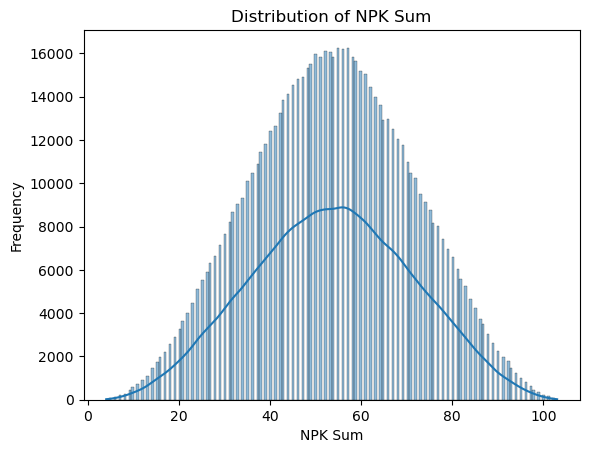

In [11]:
sns.histplot(data=df, x='NPK', kde=True)
plt.pyplot.title('Distribution of NPK Sum')
plt.pyplot.xlabel('NPK Sum')
plt.pyplot.ylabel('Frequency')
plt.pyplot.show()

In [20]:
# prompt: add feature npk level with 3 values low, moderate, high
def create_npk_level(df):
    bins = [0, 20, 40, 60, 80, float('inf')]  # Define bins for low, moderate, and high
    labels = [1, 2, 3, 4, 5] # Define labels for the bins
    df['NPK_level'] = pd.cut(df['NPK'], bins=bins, labels=labels, right=False).astype(int)
    return df

df = create_npk_level(df)
df[['NPK', 'NPK_level']].head(10)

,NPK,NPK_level
0,45,3
1,54,3
2,52,3
3,55,3
4,55,3
5,19,1
6,63,4
7,77,4
8,65,4
9,53,3


## Model

In [21]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,750000.0,NaN,NaN,NaN,374999.5,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
temp,750000.0,NaN,NaN,NaN,31.503565,4.025574,25.0,28.0,32.0,35.0,38.0
humi,750000.0,NaN,NaN,NaN,61.038912,6.647695,50.0,55.0,61.0,67.0,72.0
mois,750000.0,NaN,NaN,NaN,45.184147,11.794594,25.0,35.0,45.0,55.0,65.0
soil,750000,5,Sandy,156710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop,750000,11,Paddy,85754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N,750000.0,NaN,NaN,NaN,23.093808,11.216125,4.0,13.0,23.0,33.0,42.0
K,750000.0,NaN,NaN,NaN,9.478296,5.765622,0.0,4.0,9.0,14.0,19.0
P,750000.0,NaN,NaN,NaN,21.073227,12.346831,0.0,10.0,21.0,32.0,42.0
fert,750000,7,14-35-14,114436,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# prompt: check sum of infinity values in all cols

# Check for infinity values in all columns
infinite_counts = df.isin([np.inf, -np.inf]).sum()

# Print the count of infinite values for each column
print("Count of infinite values per column:")
infinite_counts

Count of infinite values per column:


id           0
temp         0
humi         0
mois         0
soil         0
crop         0
N            0
K            0
P            0
fert         0
temp_diff    0
humi_diff    0
mois_diff    0
N_diff       0
K_diff       0
P_diff       0
soil_crop    0
N_K          0
N_P          0
P_K          0
NPK          0
NPK_level    0
dtype: int64

In [24]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import numpy as np
import pandas as pd

# Custom evaluation function
def top_3_score(y_true, y_pred_proba, classes):
    scores = []
    for true_label, probas in zip(y_true, y_pred_proba):
        top3 = np.argsort(probas)[::-1][:3]
        top3_labels = classes[top3]
        if true_label == top3_labels[0]:
            scores.append(1.0)
        elif true_label == top3_labels[1]:
            scores.append(0.5)
        elif true_label == top3_labels[2]:
            scores.append(1/3)
        else:
            scores.append(0)
    return np.mean(scores)

# Define features/target
features = [col for col in df.columns if col not in ['id', 'fert']]
target = 'fert'

X = df[features]
y = df[target]

# Separate categorical/numerical
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Ensure 'npk_level' is in numerical
if 'npk_level' in categorical_features:
    categorical_features.remove('npk_level')
    numerical_features.append('npk_level')

# Preprocessing
transformers = [
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numerical_features)
]
preprocessor = ColumnTransformer(transformers=transformers)

# Model
lgb_model = lgb.LGBMClassifier(objective='multiclass', num_class=len(y.unique()))

# CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', lgb_model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_val)
    score = top_3_score(y_val.values, y_pred_proba, pipeline.named_steps['classifier'].classes_)
    scores.append(score)

    print(f"Fold {fold + 1} Top-3 Score: {score:.4f}")

print(f"\nAverage Top-3 Score: {np.mean(scores):.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1361
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.885565
[LightGBM] [Info] Start training from score -1.877350
[LightGBM] [Info] Start training from score -1.900582
[LightGBM] [Info] Start training from score -1.909654
[LightGBM] [Info] Start training from score -1.910836
[LightGBM] [Info] Start training from score -2.069993
[LightGBM] [Info] Start training from score -2.091474
Fold 1 Top-3 Score: 0.3186
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1363
[LightGBM] [Info] Number of data points in th

In [25]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import numpy as np
import pandas as pd

# Custom top-3 scoring function
def top_3_score(y_true, y_pred_proba, classes):
    scores = []
    for true_label, probas in zip(y_true, y_pred_proba):
        top3 = np.argsort(probas)[::-1][:3]
        top3_labels = classes[top3]
        if true_label == top3_labels[0]:
            scores.append(1.0)
        elif true_label == top3_labels[1]:
            scores.append(0.5)
        elif true_label == top3_labels[2]:
            scores.append(1/3)
        else:
            scores.append(0)
    return np.mean(scores)

# Encode target labels
le = LabelEncoder()
df['fert_encoded'] = le.fit_transform(df['fert'])

# Define features/target
features = [col for col in df.columns if col not in ['id', 'fert', 'fert_encoded']]
target = 'fert_encoded'

X = df[features]
y = df[target]

# Separate categorical/numerical
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Ensure 'npk_level' is numerical
if 'npk_level' in categorical_features:
    categorical_features.remove('npk_level')
    numerical_features.append('npk_level')

# Preprocessor
transformers = [
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numerical_features)
]
preprocessor = ColumnTransformer(transformers=transformers)

# Models
lgb_model = lgb.LGBMClassifier(objective='multiclass', num_class=len(np.unique(y)))
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_lgb = []
scores_lr = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # LightGBM pipeline
    pipeline_lgb = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', lgb_model)
    ])
    pipeline_lgb.fit(X_train, y_train)
    y_pred_lgb = pipeline_lgb.predict_proba(X_val)
    score_lgb = top_3_score(y_val.values, y_pred_lgb, pipeline_lgb.named_steps['classifier'].classes_)
    scores_lgb.append(score_lgb)

    # Logistic Regression pipeline
    pipeline_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', log_reg)
    ])
    pipeline_lr.fit(X_train, y_train)
    y_pred_lr = pipeline_lr.predict_proba(X_val)
    score_lr = top_3_score(y_val.values, y_pred_lr, pipeline_lr.named_steps['classifier'].classes_)
    scores_lr.append(score_lr)

    print(f"Fold {fold + 1} - LGBM Top-3: {score_lgb:.4f} | Logistic Regression Top-3: {score_lr:.4f}")

print(f"\nAverage Top-3 Score - LGBM: {np.mean(scores_lgb):.4f}")
print(f"Average Top-3 Score - Logistic Regression: {np.mean(scores_lr):.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1361
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.885565
[LightGBM] [Info] Start training from score -1.877350
[LightGBM] [Info] Start training from score -1.900582
[LightGBM] [Info] Start training from score -1.909654
[LightGBM] [Info] Start training from score -1.910836
[LightGBM] [Info] Start training from score -2.069993
[LightGBM] [Info] Start training from score -2.091474


C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 - LGBM Top-3: 0.3186 | Logistic Regression Top-3: 0.2904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1363
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.884127
[LightGBM] [Info] Start training from score -1.878996
[LightGBM] [Info] Start training from score -1.898432
[LightGBM] [Info] Start training from score -1.914221
[LightGBM] [Info] Start training from score -1.909800
[LightGBM] [Info] Start training from score -2.066328
[LightGBM] [Info] Start training from score -2.093338


C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 - LGBM Top-3: 0.3186 | Logistic Regression Top-3: 0.2913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.883568
[LightGBM] [Info] Start training from score -1.880350
[LightGBM] [Info] Start training from score -1.895100
[LightGBM] [Info] Start training from score -1.912042
[LightGBM] [Info] Start training from score -1.909575
[LightGBM] [Info] Start training from score -2.069320
[LightGBM] [Info] Start training from score -2.096222


...

Fold 3 - LGBM Top-3: 0.3181 | Logistic Regression Top-3: 0.2895
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1363
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.888105
[LightGBM] [Info] Start training from score -1.883151
[LightGBM] [Info] Start training from score -1.898198
[LightGBM] [Info] Start training from score -1.908642
[LightGBM] [Info] Start training from score -1.906105
[LightGBM] [Info] Start training from score -2.064553
[LightGBM] [Info] Start training from score -2.096561


C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 - LGBM Top-3: 0.3209 | Logistic Regression Top-3: 0.2916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 88
[LightGBM] [Info] Start training from score -1.882976
[LightGBM] [Info] Start training from score -1.880449
[LightGBM] [Info] Start training from score -1.895388
[LightGBM] [Info] Start training from score -1.913170
[LightGBM] [Info] Start training from score -1.909294
[LightGBM] [Info] Start training from score -2.068172
[LightGBM] [Info] Start training from score -2.096642


C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5 - LGBM Top-3: 0.3177 | Logistic Regression Top-3: 0.2890

Average Top-3 Score - LGBM: 0.3188
Average Top-3 Score - Logistic Regression: 0.2904


## Evaluation

In [ ]:
# Get class probabilities
y_proba = model.predict_proba(X_test)

# Create DataFrame
proba_df = pd.DataFrame(y_proba, columns=model.classes_)

proba_df["true_label"] = y_test.values

In [ ]:
# Get the rank of each class for each row (higher prob = lower rank number)
# argsort gives ascending order, so we reverse it with [::-1]
ranked_indices = np.argsort(-y_proba, axis=1)

# Map index positions to class labels
ranked_labels = model.classes_[ranked_indices]

# Get the rank of the true label for each row
true_ranks = [
    list(ranked).index(true_label) + 1  # +1 because index starts from 0
    for ranked, true_label in zip(ranked_labels, y_test)
]

# Add to DataFrame
proba_df["true_label_rank"] = true_ranks

print(f'Accuracy: {len(proba_df[proba_df["true_label_rank"] <= 3])/len(proba_df)}')

In [ ]:
proba_df.head()

In [ ]:
def mapk(true_label_ranks, k=3):
    total_score = 0
    for rank in true_label_ranks:
        if (rank > 3):
            continue

        total_score += 1 / rank

    return total_score / len(true_label_ranks)

In [ ]:
print("MAP@3:", mapk(proba_df['true_label_rank']))